<a href="https://colab.research.google.com/github/Abishekabi19/ML-and-DL-Project/blob/main/Medical_insurance/medical_insurance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statement
The healthcare industry faces significant challenges in accurately estimating medical insurance costs due to the influence of multiple factors such as age, income, lifestyle habits, medical history, and risk conditions. Insurance providers need reliable predictive systems to estimate medical expenses and insurance premiums in order to design appropriate policies, manage financial risk, and ensure fair pricing for customers.

The objective of this project is to develop a Machine Learning–based Medical Insurance Cost Prediction System that analyzes demographic information, health indicators, medical history, and policy-related attributes to predict key insurance-related outcomes such as annual medical cost, insurance premium, or high-risk status. The system uses historical insurance data containing features like age, BMI, smoking habits, chronic diseases, hospitalization records, and medical procedures to train predictive models.

By applying data preprocessing, feature engineering, and machine learning algorithms, the system aims to identify patterns and relationships between patient characteristics and insurance costs. The final model helps insurance companies make data-driven decisions, improve risk assessment accuracy, and optimize premium pricing strategies.

This project enhances efficiency, reduces manual estimation errors, and supports intelligent healthcare insurance management through accurate and automated predictions.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/medical_insurance.csv')
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [ ]:
df.isnull().sum()

,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


<Axes: >

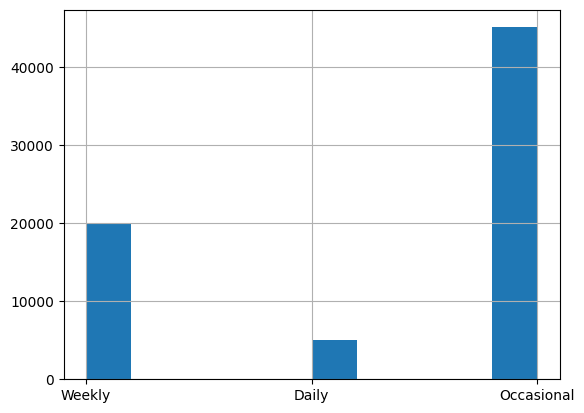

In [ ]:
df['alcohol_freq'].hist()

In [ ]:
df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0],inplace=True)

/tmp/ipython-input-3873672432.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0],inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
dumpies=pd.get_dummies(df['sex']).astype(int)
dumpies

,Female,Male,Other
0,1,0,0
1,1,0,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
99995,0,1,0
99996,0,1,0
99997,0,1,0
99998,1,0,0


In [ ]:
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


In [ ]:
df=pd.concat([df,dumpies],axis=1)
df.drop('sex',axis=1,inplace=True)

In [ ]:
df['region'].unique()

array(['North', 'Central', 'West', 'South', 'East'], dtype=object)

In [ ]:
df['urban_rural'].unique()

array(['Suburban', 'Urban', 'Rural'], dtype=object)

In [ ]:
df['education'].unique()

array(['Doctorate', 'No HS', 'HS', 'Some College', 'Masters', 'Bachelors'],
      dtype=object)

In [ ]:
df['education'].replace([ 'No HS', 'HS', 'Some College','Bachelors', 'Masters', 'Doctorate'],[0,1,2,3,4,5],inplace=True)

/tmp/ipython-input-244766416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].replace([ 'No HS', 'HS', 'Some College','Bachelors', 'Masters', 'Doctorate'],[0,1,2,3,4,5],inplace=True)
/tmp/ipython-input-244766416.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['education'].r

In [ ]:
df['marital_status'].unique()

array(['Married', 'Single', 'Divorced', 'Widowed'], dtype=object)

In [ ]:
df['employment_status'].unique()

array(['Retired', 'Employed', 'Self-employed', 'Unemployed'], dtype=object)

In [ ]:
df['smoker'].unique()

array(['Never', 'Current', 'Former'], dtype=object)

In [ ]:
df['smoker'].replace(['Never','Former','Current'],[0,1,2],inplace=True)

/tmp/ipython-input-4261118211.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['smoker'].replace(['Never','Former','Current'],[0,1,2],inplace=True)
/tmp/ipython-input-4261118211.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'].replace(['Never','Former','Current'],[0,1,2],inplac

In [ ]:
df['alcohol_freq'].unique()

array(['Occasional', 'Weekly', 'Daily'], dtype=object)

In [ ]:
df['alcohol_freq'].replace(['Occasional', 'Weekly', 'Daily'],[0,1,2],inplace=True)

/tmp/ipython-input-3436284729.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_freq'].replace(['Occasional', 'Weekly', 'Daily'],[0,1,2],inplace=True)
/tmp/ipython-input-3436284729.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['alcohol_freq'].replace(['Occasional', 'Weekly', '

In [ ]:
df['plan_type'].unique()

array(['PPO', 'POS', 'HMO', 'EPO'], dtype=object)

In [ ]:
df['network_tier'].unique()

array(['Bronze', 'Gold', 'Platinum', 'Silver'], dtype=object)

In [ ]:
df['network_tier'].replace(['Bronze','Silver', 'Gold', 'Platinum'],[0,1,2,3],inplace=True)

/tmp/ipython-input-3114094266.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['network_tier'].replace(['Bronze','Silver', 'Gold', 'Platinum'],[0,1,2,3],inplace=True)
/tmp/ipython-input-3114094266.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['network_tier'].replace(['Bronze','Silver'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   region                       100000 non-null  object 
 3   urban_rural                  100000 non-null  object 
 4   income                       100000 non-null  float64
 5   education                    100000 non-null  int64  
 6   marital_status               100000 non-null  object 
 7   employment_status            100000 non-null  object 
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  int64  
 12  alcohol_freq                 100000 non-null  int64  
 13  

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['marital_status']=le.fit_transform(df['marital_status'])
df['employment_status']=le.fit_transform(df['employment_status'])
df['plan_type']=le.fit_transform(df['plan_type'])
df['region']=le.fit_transform(df['region'])
df['urban_rural']=le.fit_transform(df['urban_rural'])

<Axes: >

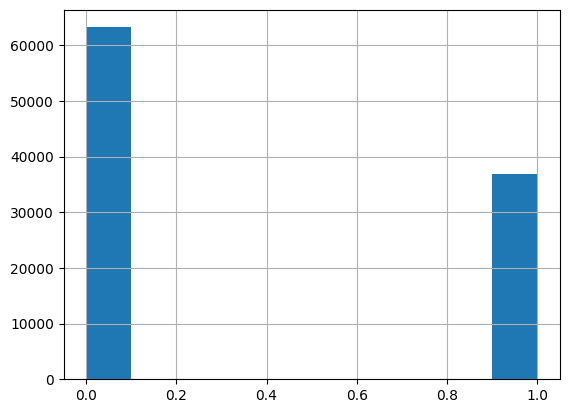

In [ ]:
df['is_high_risk'].hist()

In [ ]:
X=df.drop(columns=['is_high_risk'])
y=df['is_high_risk']

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_smote,y_smote=smote.fit_resample(X,y)

df_smote=pd.concat([pd.DataFrame(X_smote,columns=X.columns),
                   pd.Series(y_smote,name=y.name)],axis=1)
df=df_smote

<Axes: >

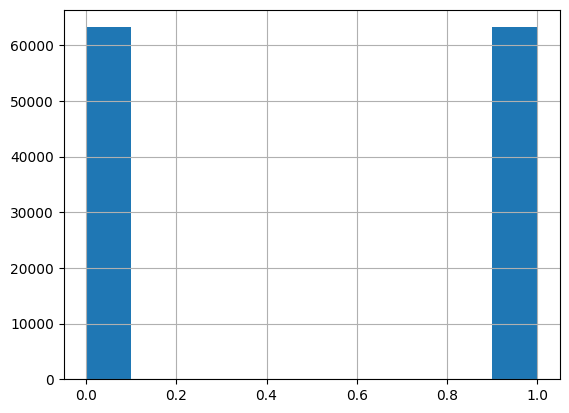

In [ ]:
df['is_high_risk'].hist()

In [ ]:
df

,person_id,age,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,had_major_procedure,Female,Male,Other,is_high_risk
0,75722,52,2,1,22700.000000,5,1,1,3,1,...,1,0,2,0,1,0,1,0,0,0
1,80185,79,2,2,12800.000000,0,1,0,3,1,...,0,0,1,0,1,0,1,0,0,1
2,19865,68,2,0,40700.000000,1,1,1,5,3,...,1,0,2,1,0,0,0,1,0,1
3,76700,15,2,1,15600.000000,2,1,2,5,3,...,1,0,0,1,0,0,0,1,0,0
4,92992,53,0,1,89600.000000,5,1,2,2,0,...,2,0,1,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126433,24087,63,1,1,84304.829956,1,1,1,2,0,...,0,0,0,0,0,0,0,1,0,1
126434,72847,64,1,2,64900.000000,2,1,1,3,1,...,0,0,0,2,1,0,1,0,0,1
126435,60462,52,0,0,11377.413140,2,1,0,1,0,...,1,0,0,0,0,0,1,0,0,1
126436,36599,67,2,2,82100.793805,3,1,1,2,0,...,0,0,0,0,0,0,0,0,0,1


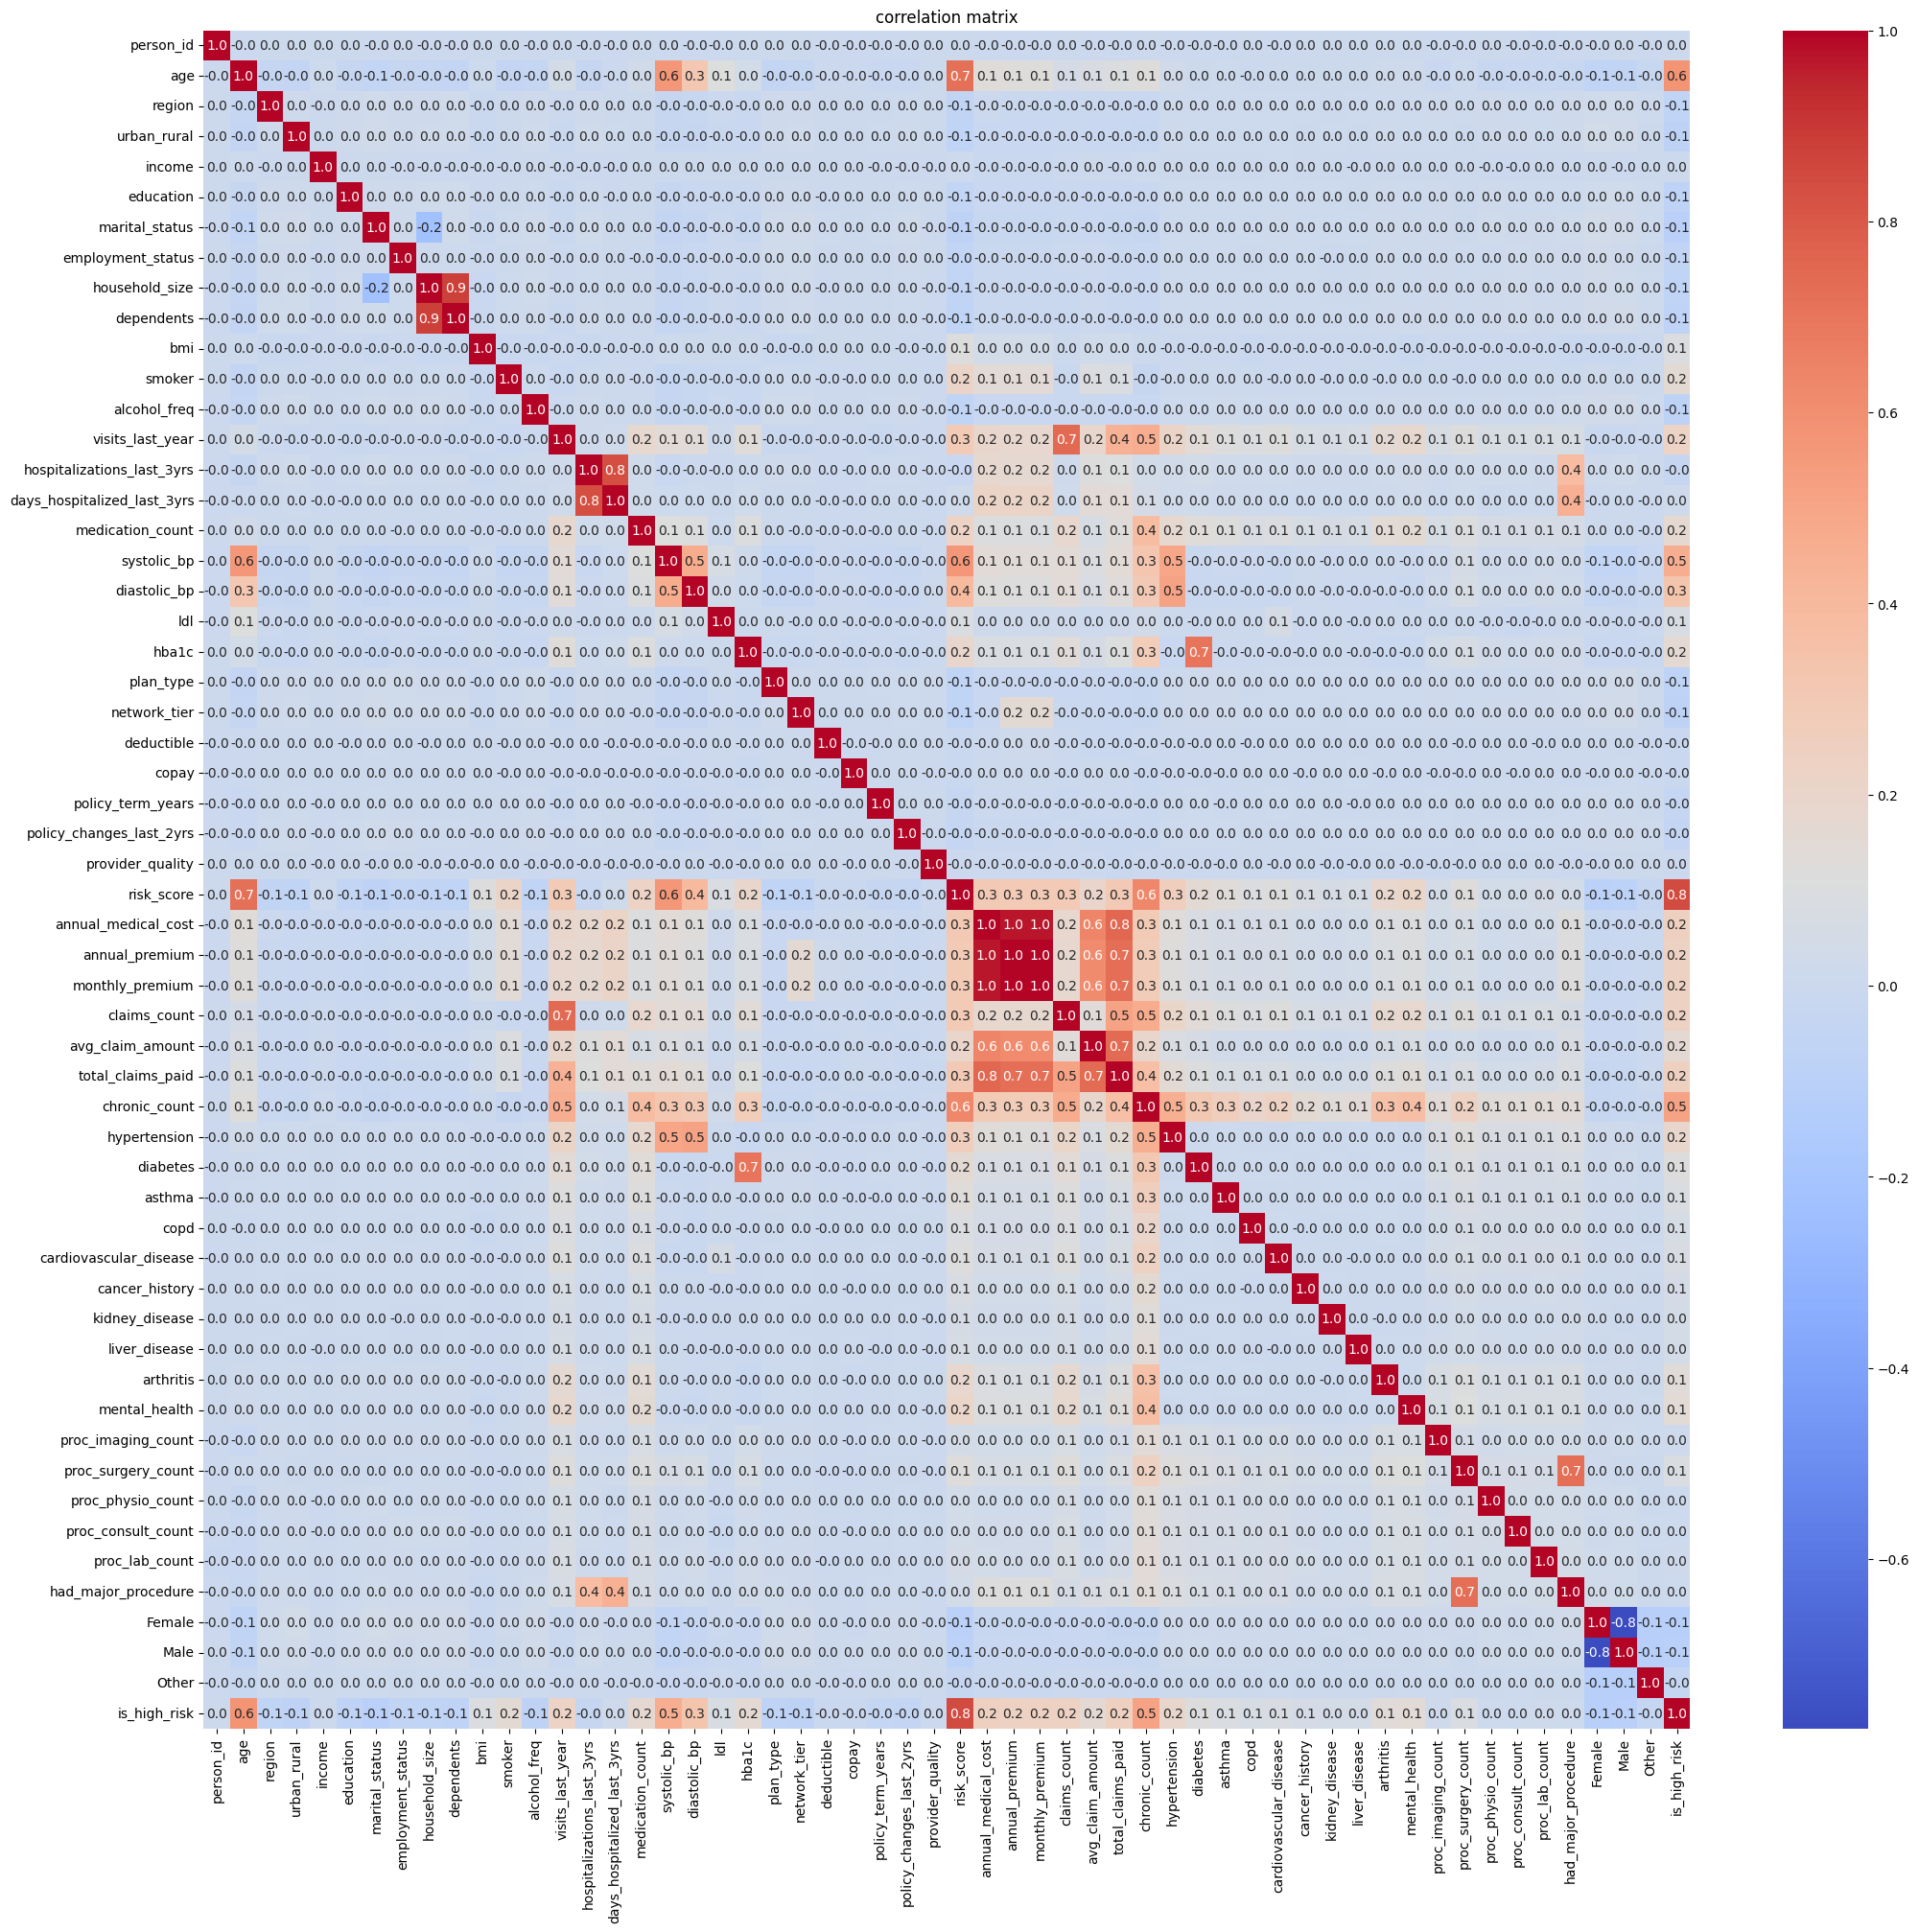

In [ ]:
plt.figure(figsize=(25,23))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop(['dependents','days_hospitalized_last_3yrs'],axis=1,inplace=True)

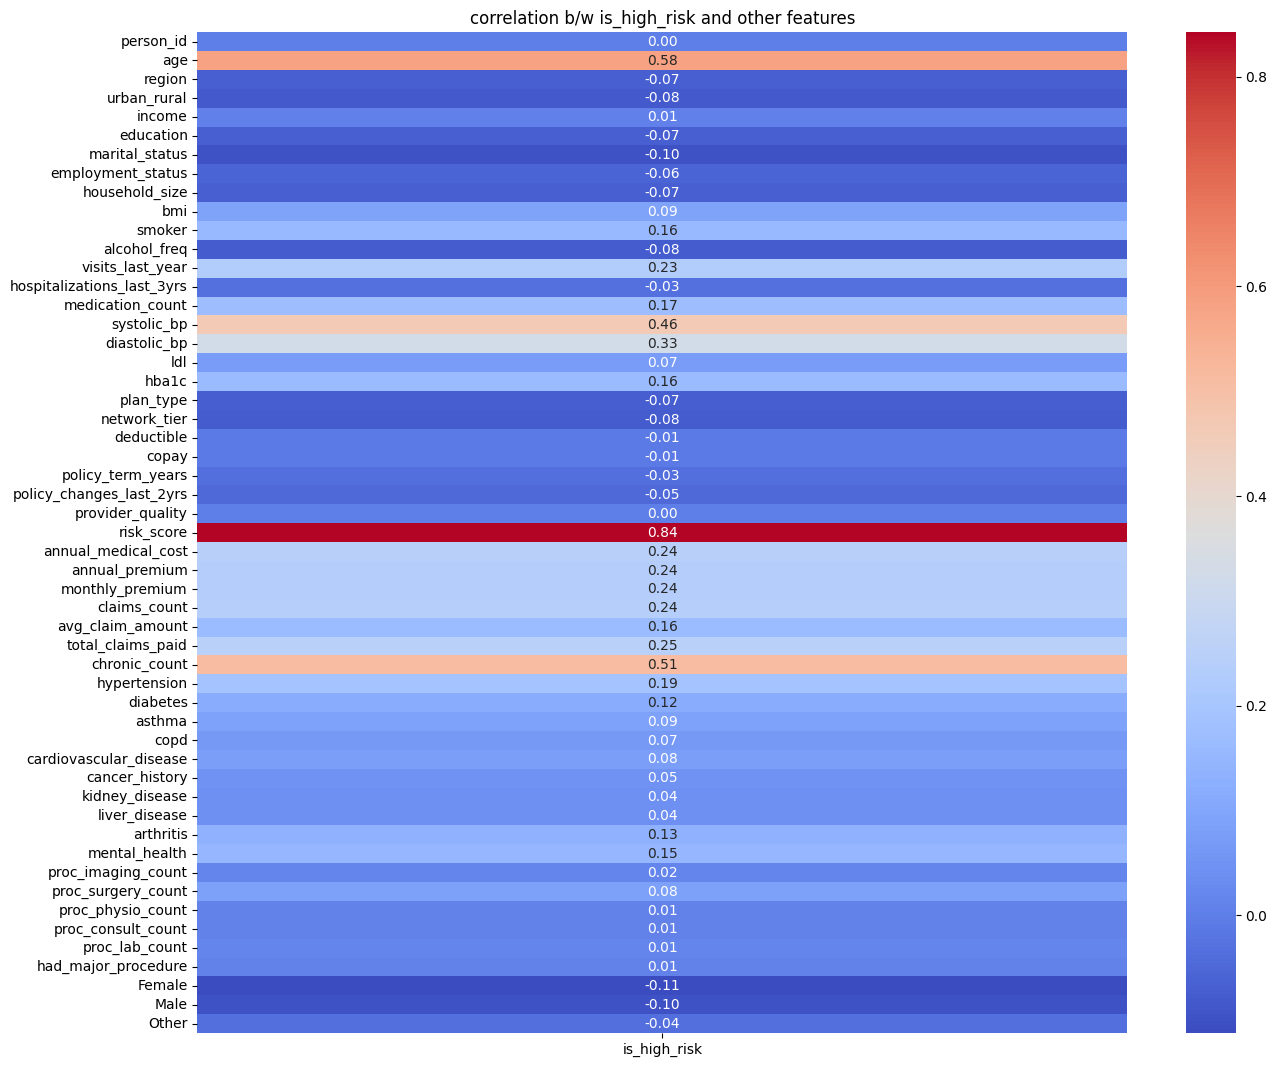

In [ ]:
plt.figure(figsize=(15,13))
high_risk_matrix=df.corr()['is_high_risk']
high_risk_matrix=high_risk_matrix.drop('is_high_risk')
sns.heatmap(high_risk_matrix.to_frame(),annot=True,fmt='0.2f',cmap='coolwarm',annot_kws={'size':10})
plt.title('correlation b/w is_high_risk and other features')
plt.show()

In [ ]:
df.drop(['Other','had_major_procedure','proc_lab_count','proc_consult_count','proc_physio_count','proc_imaging_count',
         'kidney_disease','liver_disease','provider_quality','deductible','copay','policy_term_years','hospitalizations_last_3yrs',
         'income','person_id'],axis=1,inplace=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
features=['age','region',	'urban_rural','education','marital_status',	'employment_status','household_size',	'bmi','smoker',
          'alcohol_freq',	'visits_last_year', 'medication_count','systolic_bp','diastolic_bp','ldl','hba1c','plan_type','network_tier'
           ,'policy_changes_last_2yrs','risk_score','annual_medical_cost','annual_premium','monthly_premium' ,'claims_count',
          'avg_claim_amount','total_claims_paid','chronic_count','hypertension','diabetes',	'asthma',	'copd',	'cardiovascular_disease',	'cancer_history',	'arthritis',	'mental_health','proc_surgery_count',	'Female',
          'Male']
scaled=scale.fit_transform(df[features])
df_scaled=pd.DataFrame(scaled,columns=features)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x=df_scaled
y=df['is_high_risk']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression()

best_accuracy=0
best_fold=-1

best_x_train=None
best_x_test=None
best_y_train=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_pred,y_test)
  print(f'accuracy:{acc}')

  if acc>best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_x_train=x_train
    best_y_train=y_train
    best_x_test=x_test
    best_y_test=y_test
    best_y_pred=y_pred
print(f'\n Best fold:{best_fold} with accuracy:{best_accuracy}')


accuracy:0.9961641885479279
accuracy:0.9944242328377095
accuracy:0.9957291996203733
accuracy:0.9956894847154665
accuracy:0.9950962945386957

 Best fold:1 with accuracy:0.9961641885479279


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model= DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

1.0

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

1.0

In [ ]:
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(256,activation='relu',input_shape=(38,)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_x_train,best_y_train,epochs=40,batch_size=32)

Epoch 1/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9409 - loss: 0.1345
Epoch 2/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9785 - loss: 0.0490
Epoch 3/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9836 - loss: 0.0386
Epoch 4/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9837 - loss: 0.0365
Epoch 5/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9887 - loss: 0.0286
Epoch 6/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9877 - loss: 0.0300
Epoch 7/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9885 - loss: 0.0277
Epoch 8/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9891 - loss: 0.0255
Epoch 9/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9903 - loss: 0.0239
Epoch 10/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9902 - loss: 0.0239
Epoch 11/40
3161/3161 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9911 - loss: 0.0217
Epoch 12/40
3161/3161 

In [ ]:
y_pred=model.predict(best_x_test)
loss,accuracy=model.evaluate(best_x_test,best_y_test)
print(f'Accuracy:{accuracy}')

791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9937 - loss: 0.0149
Accuracy:0.9939892292022705


In [ ]:
import pickle
with open('medical_insurance DL Model.plk',"wb") as file:
  pickle.dump(model,file)

In [ ]:
with open('/content/medical_insurance DL Model.plk',"rb") as file:
  load_model=pickle.load(file)

# Conclusion

In this project, we developed a Medical Insurance Risk Prediction System using Machine Learning and Deep Learning techniques. We used K-Fold Cross Validation to evaluate model performance. In Machine Learning, Decision Tree and Random Forest were implemented, while in Deep Learning, an ANN model was used. After comparing both approaches, the Deep Learning model showed better performance and accuracy. Therefore, the Deep Learning model was selected as the final model. Finally, the trained model was saved in Pickle format for future predictions and deployment